In [1]:
import os
import importlib
import train_utils
import pandas as pd
import numpy as np

importlib.reload(train_utils)  # 重新加载模块

os.chdir("c:\\Users\\HANJ29\\Applications\\deepstock\\")

from train_utils import (
    load_train_test_dataset,
    train_model,
    save_model,
    print_fit_report,
    draw_learning_curve,
    save_training_results,
    print_label_distribution,
)


freq = "M"
version = "0.2"
model_name = "RF"
labels = [
    "top_or_bottom",
    "top_or_bottom_stat",
    "top_bottom_volatility_stat",
    "top_or_bottom_optimized",
    "top_or_bottom_stat_optimized",
    "top_bottom_volatility_optimized",
]
features = [
    "change",
    "pct_chg",
    "vol",  # 0.02
    "atr",
    "pct_vol_chg",
    "pct_o2c",
    "lower_shadow",
    "upper_shadow",
    "dif",  # 0.02
    "dea",  # 0.02
    "bar",
    "rsi_6",
    "rsi_12",
    "rsi_24",
    "k",
    "d",
    "j",
    "turnover_rate",
    "turnover_rate_f",
    "volume_ratio",
    # "pe",
    # "pe_ttm", 当为负值时得到的数据为NaN
    "pb",#!
    "ps",  # 0.02!
    "ps_ttm",  # 0.02
    "dv_ratio",  # 0.02
    "dv_ttm",  # 0.02
    "total_share",  # 0.02
    "float_share",  # 0.02 !
    "free_share", #!
    "total_mv",  # 0.02!
    "circ_mv",  # 0.02
    "float_share_ratio",  ## 0.02!
    "free_share_ratio",  # 0.02
    "mab_10",
    "mab_25",
    # "volatility_ratio",# !
    # "shadow_ratio",# !
    # "skewness",
    # "kurtosis",
]
features_high = [
    "change",
    "pct_chg",
    "vol",  # 0.02
    "atr",
    "pct_vol_chg",
    "pct_o2c",
    "lower_shadow",
    "upper_shadow",
    "dif",  # 0.02
    "dea",  # 0.02
    "bar",
    "rsi_6",
    "rsi_12",
    "rsi_24",
    "k",
    "d",
    "j",
    "turnover_rate",
    "turnover_rate_f",
    "volume_ratio",
    # "pe",
    # "pe_ttm", 当为负值时得到的数据为NaN
    "pb",#!
    "ps",  # 0.02!
    "ps_ttm",  # 0.02
    # "dv_ratio",  # 0.02
    # "dv_ttm",  # 0.02
    "total_share",  # 0.02
    "float_share",  # 0.02 !
    "free_share", #!
    "total_mv",  # 0.02!
    "circ_mv",  # 0.02
    # "float_share_ratio",  ## 0.02!
    "free_share_ratio",  # 0.02
    "mab_10",
    "mab_25",
    "volatility_ratio",# 
    "shadow_ratio",# 
    # "skewness",
    # "kurtosis",
]

c:\Users\HANJ29\Applications\venv-stock-insider-admin\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
version = 0.2
X_train, X_test, y_train, y_test = load_train_test_dataset(
    freq=freq,
    version=version,
    features=features,
)

Train dataset loaded from C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/dataset_training\train_dataset_M_0.2.csv
Test dataset loaded from C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/dataset_training\test_dataset_M_0.2.csv
split train data to X and y
X_train shape: (393793, 34), y_train shape: 6
split test data to X and y
X_test shape: (173896, 34), y_test shape: 6


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

X_y_combined= pd.concat([X_train, y_train["top_or_bottom_optimized"]], axis=1)
# 可视化类别1和2的特征分布
for feature in features:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(X_train[y_train['top_or_bottom_optimized'] == 1][feature], label='Class 1', shade=True)
    sns.kdeplot(X_train[y_train['top_or_bottom_optimized'] == 2][feature], label='Class 2', shade=True)
    plt.title(f"Feature Distribution: {feature}")
    plt.legend()
    plt.show()

In [54]:
label = "top_bottom_volatility_optimized"

In [5]:
X_train['volatility_ratio'] = X_train['pct_vol_chg'] / (X_train['atr'] + 1e-5)
X_train['shadow_ratio'] = X_train['lower_shadow'] / (X_train['upper_shadow'] + 1e-5)
# X_train['skewness'] = X_train['pct_chg'].skew()
# X_train['kurtosis'] = X_train['pct_chg'].kurt()

In [6]:
X_train_high = X_train[features_high]

In [ ]:
X_train_raw = pd.read_csv("C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/dataset_training/train_dataset_M_0.1.csv")
X_test_raw = pd.read_csv("C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/dataset_training/test_dataset_M_0.1.csv")

模型code
- LR - logistic regression
- RF - random forest
- SVM - support vector machine
- ANN - artificial neural network
- DT - decision tree
- GBM - gradient boosting machine
- XGB - extreme gradient boosting
- LGB - light gradient boosting
- CAT - catboost


In [7]:
print_label_distribution(y_train[label])

Current label distribution:
top_or_bottom_optimized
0    256367
1     69399
2     68027
Name: count, dtype: int64


In [55]:
from imblearn.under_sampling import RandomUnderSampler

# 获取每个类别的数量
COUNT_PER_CLASS = 50000 # 每个类别的样本数量
class_counts = y_train[label].value_counts()
print("原始类别分布:")
print(class_counts)

# 确定少数类的数量
minority_class_counts = class_counts.min()
majority_class_counts = class_counts.max()


原始类别分布:
top_bottom_volatility_optimized
0    372066
1     12051
2      9676
Name: count, dtype: int64


In [56]:
# sampling_strategy = {0: minority_class_counts}  # 类别 0 保持 1000，类别 1 和 2 过采样到 500
sampling_strategy = {0: int(minority_class_counts * 3.5), }
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train[label])

In [57]:
X_resampled['volatility_ratio'] = X_resampled['pct_vol_chg'] / (X_resampled['atr'] + 1e-5)
X_resampled['shadow_ratio'] = X_resampled['lower_shadow'] / (X_resampled['upper_shadow'] + 1e-5)

In [58]:
X_resampled_high = X_resampled[features_high]   

In [59]:
y_resampled.value_counts()

top_bottom_volatility_optimized
0    33866
1    12051
2     9676
Name: count, dtype: int64

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import mutual_info_classif

mutual_info = mutual_info_classif(X_resampled, y_resampled, random_state=42,)
print(mutual_info)

In [ ]:
from sklearn.feature_selection import f_classif

f_values, p_values = f_classif(X_train, y_train["top_or_bottom_optimized"])
print(f_values)

In [ ]:
from sklearn.feature_selection import f_classif

f_values, p_values = f_classif(X_resampled, y_resampled)
print(f_values)

In [ ]:
# 计算每个类别的权重
class_weights = {
    0: 1,
    1: len(y_train["top_or_bottom_optimized"])
    / sum(y_train["top_or_bottom_optimized"] == 1),
    2: len(y_train["top_or_bottom_optimized"])
    / sum(y_train["top_or_bottom_optimized"] == 2),
}

# 为每个样本分配权重
sample_weights = np.array(
    [class_weights[label] for label in y_train["top_or_bottom_optimized"]]
)
sample_weights

In [3]:
# 训练模型
# Current label distribution:
# top_or_bottom_optimized
# 0    268571
# 2     72591
# 1     72369
def get_hyper_param(param_name):
    # 定义随机森林分类器的超参数
    RF = {
        'n_estimators': 200,#200,#1000,#500,#400,#300,#200,#100,          # 初始树的数量，适中即可，后续可增加
        'max_depth': None,#50,#None,#50,#30,#50,#30,#None,            # 不限制树的深度，观察模型是否过拟合
        'min_samples_split': 10,#5,#20,#10,#20,#10,      # 内部节点再分裂所需的最小样本数
        'min_samples_leaf': 5,#15,#5,#10,#5,        # 叶子节点的最小样本数，防止过拟合
        'max_features': 'sqrt',       # 每次分裂时考虑的最大特征数，sqrt 是推荐值
        'class_weight': {0: 1, 1: 3.5, 2: 3.5},#"balanced_subsample",#"balanced",#{0: 1, 1: 10, 2: 10},#"balanced",#{0: 1, 1: 1.2, 2: 1.2},#{0: 1, 1: 3, 2: 3},#{0: 1, 1: 2, 2: 2},#{0: 1, 1: 3, 2: 3}#'balanced',   # 根据类别样本数量自动调整权重
        'random_state': 42,           # 固定随机种子，保证结果可复现
        'n_jobs': -1                  # 使用所有可用 CPU 核心进行并行计算
    }

     # 定义超参数字典
    XGB = {
         "n_estimators": 5000,  # 如果过拟合，可以适当增加
        "learning_rate": 0.01,  # 如果过拟合，可以适当减小；反之亦然
        "max_depth": 10,  # 如果过拟合，可以适当减小；反之亦然
        "min_child_weight": 7,  # 如果过拟合，可以适当增大；反之亦然
        "gamma": 1,  # 如果过拟合，可以适当增大；反之亦然
        "subsample": 0.8,  # 如果过拟合，可以适当减小；反之亦然
        "colsample_bytree": 0.8,  # 如果过拟合，可以适当减小；反之亦然
        "reg_alpha": 15,  # 如果过拟合，可以适当增大；反之亦然
        "reg_lambda": 25,  # 如果过拟合，可以适当增大；反之亦然
        "objective": "multi:softmax",  # 多分类
        "num_class": 3,  # 类别数
        "eval_metric": "mlogloss",  # 评价指标
        # "early_stopping_rounds": 50, #早停轮数
        # "use_label_encoder": False,  # 避免警告
        "random_state": 42,  # 随机种子
        "n_jobs": -1,  # 使用所有可用 CPU 核心进行并行计算
        "verbosity": 1,  # 输出详细信息
    }
    # 超参数
    LGBM = {
        'objective': 'multiclass',    # 多分类问题
        'num_class': 3,               # 类别数量（根据实际类别数调整）
        'learning_rate': 0.05,         # 初始学习率
        'max_depth': -1,              # 不限制树的深度，观察是否过拟合
        'num_leaves': 31,             # 每棵树的最大叶子数，控制模型复杂度
        'min_data_in_leaf': 20,       # 每个叶子节点的最小样本数，防止过拟合
        'feature_fraction': 0.8,      # 每棵树使用的特征比例
        'bagging_fraction': 0.8,      # 每棵树使用的样本比例
        'bagging_freq': 5,            # 每 5 次迭代进行一次样本重采样
        'lambda_l1': 0.0,             # L1 正则化
        'lambda_l2': 0.0,             # L2 正则化
        'n_estimators': 1000,#500,#200,          # 初始树的数量
        'random_state': 42,           # 固定随机种子
        'n_jobs': -1                  # 使用所有 CPU 核心
    }
    # 定义超参数字典
    CAT = {
        'loss_function': 'MultiClass',  # 多分类问题
        'learning_rate': 0.1,          # 初始学习率
        'depth': 6,                    # 树的深度，控制模型复杂度
        'iterations': 1000,            # 最大迭代次数（树的数量）
        'l2_leaf_reg': 3,              # L2 正则化系数，防止过拟合
        'border_count': 32,            # 特征分箱的边界数量，默认 32
        'random_strength': 1,          # 控制分裂时的随机性，防止过拟合
        'bagging_temperature': 1,      # 控制样本权重的随机性，1 为默认值
        'class_weights': None,         # 类别权重，若类别不平衡可设置
        'random_seed': 42,             # 固定随机种子
        'thread_count': -1             # 使用所有 CPU 核心
    }
    local_vars = locals()
    if param_name in local_vars:
        return local_vars[param_name]
    else:
        raise ValueError(f"Parameter '{param_name}' not found.")

In [9]:
model_name = "XGB"
params = get_hyper_param(model_name)
params

{'n_estimators': 5000,
 'learning_rate': 0.01,
 'max_depth': 10,
 'min_child_weight': 7,
 'gamma': 1,
 'subsample': 0.8,
 'colsample_bytree': 0.8,
 'reg_alpha': 15,
 'reg_lambda': 25,
 'objective': 'multi:softmax',
 'num_class': 3,
 'eval_metric': 'mlogloss',
 'random_state': 42,
 'n_jobs': -1,
 'verbosity': 1}

In [ ]:
from imblearn.over_sampling import SMOTE

def resample(X, y, label, class_counts, target_per_class, minority_class_counts=None):
    sampling_strategy = {1: int(class_counts * target_per_class), 2: int(class_counts * target_per_class)}  # 类别 0 保持 1000，类别 1 和 2 过采样到 500
    smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y[label])
    y_resampled.value_counts()
    return X_resampled, y_resampled

In [ ]:
X_resampled, y_resampled = resample(X_train, y_train, label, minority_class_counts, 3.5,)


In [ ]:
X_resampled_high = X_resampled[features_high]

In [ ]:
X_resampled_high.columns

In [19]:
from datetime import datetime

start_time = datetime.now()
print(f"Starting model training...{start_time}")
model = train_model(
    X_train_high, y_train[label], model_name=model_name, #with_learning_curve=True
    **params,  # 使用解包操作符将参数传递给函数
    #sample_weight=sample_weights,  # 添加样本权重参数
)
print("Model training complete.")
end_time = datetime.now()
time_diff = end_time - start_time
print(f"Model training time: {time_diff}")
print("Model training complete.")

Starting model training...2025-05-05 16:39:30.516051
Model training complete.
Model training time: 0:29:31.401214
Model training complete.


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

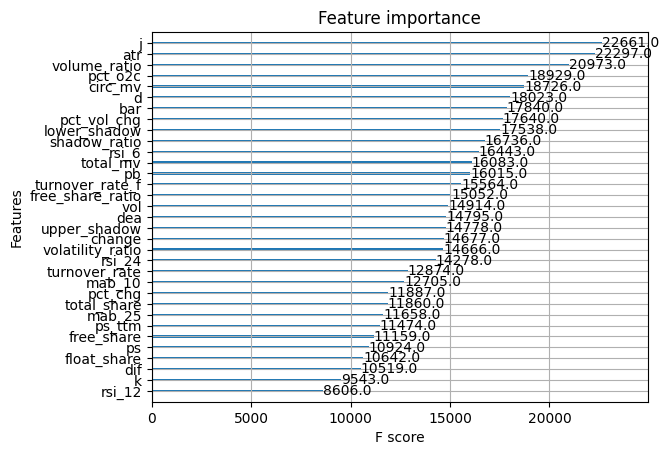

In [53]:
from xgboost import plot_importance
plot_importance(model)

In [ ]:
model = train_model(
    X_resampled, y_resampled, model_name=model_name, #with_learning_curve=True
    **params,  # 使用解包操作符将参数传递给函数
)
print("Model training complete.")

In [60]:
from datetime import datetime

start_time = datetime.now()
print(f"Starting model training...{start_time}")
model = train_model(
    X_resampled_high, y_resampled, model_name=model_name, #with_learning_curve=True
    **params,  # 使用解包操作符将参数传递给函数
)
print("Model training complete.")
end_time = datetime.now()
time_diff = end_time - start_time
print(f"Model training time: {time_diff}")
print("Model training complete.")

Starting model training...2025-05-05 18:16:24.751583
Model training complete.
Model training time: 0:04:14.185147
Model training complete.


In [61]:
print("Print fit report. train (rasampled, same category allocation)")
report_metrics_train = print_fit_report(model, X_resampled_high, y_resampled)

Print fit report. train (rasampled, same category allocation)
Recall (weighted): 0.8029
              precision    recall  f1-score   support

           0       0.81      0.89      0.85     33866
           1       0.82      0.68      0.74     12051
           2       0.76      0.65      0.70      9676

    accuracy                           0.80     55593
   macro avg       0.80      0.74      0.76     55593
weighted avg       0.80      0.80      0.80     55593



In [62]:
print("Print fit report. train")
report_metrics_train = print_fit_report(model, X_train_high, y_train[label])

Print fit report. train
Recall (weighted): 0.8430
              precision    recall  f1-score   support

           0       0.98      0.85      0.91    372066
           1       0.23      0.68      0.35     12051
           2       0.19      0.65      0.29      9676

    accuracy                           0.84    393793
   macro avg       0.46      0.73      0.51    393793
weighted avg       0.94      0.84      0.88    393793



In [4]:
X_test['volatility_ratio'] = X_test['pct_vol_chg'] / (X_test['atr'] + 1e-5)
X_test['shadow_ratio'] = X_test['lower_shadow'] / (X_test['upper_shadow'] + 1e-5)
# X_test['skewness'] = X_test['pct_chg'].skew()
# X_test['kurtosis'] = X_test['pct_chg'].kurt()

In [27]:
X_test_high = X_test[features_high]

In [65]:
from imblearn.under_sampling import RandomUnderSampler

# 获取每个类别的数量
COUNT_PER_CLASS = 50000 # 每个类别的样本数量
class_counts_test = y_test[label].value_counts()
print("原始类别分布:")
print(class_counts_test)

# 确定少数类的数量
minority_class_counts_test = class_counts_test.min()
majority_class_counts_test = class_counts_test.max()

原始类别分布:
top_bottom_volatility_optimized
0    165866
2      4179
1      3851
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import SMOTE

sampling_strategy_test = { 1: int(minority_class_counts_test * 3.2), 2: int(minority_class_counts_test * 3.2)}  # 类别 0 保持 1000，类别 1 和 2 过采样到 500
smote = SMOTE(sampling_strategy=sampling_strategy_test, random_state=42)
X_resampled_test, y_resampled_test = smote.fit_resample(X_test, y_test[label])
y_resampled_test.value_counts()

In [74]:
# sampling_strategy = {0: minority_class_counts}  # 类别 0 保持 1000，类别 1 和 2 过采样到 500
sampling_strategy = {0: int(minority_class_counts_test * 2)}
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_resampled_test, y_resampled_test = rus.fit_resample(X_test, y_test[label])
y_resampled_test.value_counts()

top_bottom_volatility_optimized
0    7702
2    4179
1    3851
Name: count, dtype: int64

In [75]:
X_resampled_test_high = X_resampled_test[features_high]

In [76]:
print("Print fit report. test (rssampled, same as training category allocation)")
report_metrics_test = print_fit_report(model, X_resampled_test_high, y_resampled_test)

Print fit report. test (rssampled, same as training category allocation)
Recall (weighted): 0.6248
              precision    recall  f1-score   support

           0       0.59      0.81      0.68      7702
           1       0.69      0.47      0.55      3851
           2       0.73      0.43      0.54      4179

    accuracy                           0.62     15732
   macro avg       0.67      0.57      0.59     15732
weighted avg       0.65      0.62      0.61     15732



In [ ]:
X_test_high = X_test[features_high]

In [77]:
print("Print fit report(raw). test")
report_metrics_test = print_fit_report(model, X_test_high, y_test[label])

Print fit report(raw). test
Recall (weighted): 0.7986
              precision    recall  f1-score   support

           0       0.97      0.82      0.89    165866
           1       0.09      0.47      0.16      3851
           2       0.12      0.43      0.19      4179

    accuracy                           0.80    173896
   macro avg       0.39      0.57      0.41    173896
weighted avg       0.93      0.80      0.85    173896



In [78]:
save_training_results(
    model_name,
    params,
    report_metrics_train,
    report_metrics_test,
    freq,
    label_values=y_test[label].value_counts(),
    output_file="training_results_M.csv",
)

Results saved to training_results_M.csv


In [ ]:
print("Start Drawing Learning Curve")
draw_learning_curve(model, X_train_high, y_train["top_or_bottom_optimized"], cv=5, scoring=None, title="Learning Curve")

In [79]:
# 保存模型
save_model(model, model_name, freq=freq, pred_type="VOLOPT")
print("Model saved.")

Model saved successfully to C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/models\XGB_VOLOPT_M.model
Model saved.


dataset内容分析和重新采样

处理周线/月线训练集重新采样

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import mutual_info_classif

mutual_info = mutual_info_classif(X_train, y_train["top_or_bottom_optimized"], random_state=42,)
print(mutual_info)

In [6]:
X_test = X_test[features_high]

In [8]:
import joblib


# 加载模型
model_name = "RF"  # 替换为你的模型名称
freq = "D"  # 替换为你的频率
pred_type = "STDOPT"  # 替换为你的预测类型

# 调用自定义的加载函数
saved_model = joblib.load(
    "C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/models/MIXED/"
    + model_name
    + "_"
    + pred_type
    + "_"
    + freq
    + ".pkl"
)
# 进行预测
print("Model Evaluation Report:")
report_metrics_test = print_fit_report(saved_model, X_test, y_test["top_or_bottom_optimized"])
print("Model evaluation complete.")

c:\Users\HANJ29\Applications\venv-stock-insider-admin\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator NearestNeighbors from version 1.6.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\HANJ29\Applications\venv-stock-insider-admin\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\HANJ29\Applications\venv-stock-insider-admin\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle 

Model Evaluation Report:
Recall (weighted): 0.3304
              precision    recall  f1-score   support

           0       0.94      0.01      0.02    109626
           1       0.31      0.89      0.46     32869
           2       0.34      0.87      0.49     31401

    accuracy                           0.33    173896
   macro avg       0.53      0.59      0.32    173896
weighted avg       0.71      0.33      0.19    173896

Model evaluation complete.
